# Creating an ellipsoid mesh

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [23]:
# Define the ellipsoid parameters
a = 4   # Semi-major axis - x
b = a   # Semi-minor axis - y
c = 1   # Semi-minor axis - z

#a = b gives a circular meshgrid along X and Y

In [ ]:
#umbilicus - belly button
#torso as the extruded obround

In [31]:
(89.5+97.5)/2

93.5

In [24]:
# Create a mesh grid
theta = np.linspace(0, np.pi, 50)          # Polar angle
phi = np.linspace(0, 2 * np.pi, 100)   # Azimuthal angle
Theta, Phi = np.meshgrid(theta, phi)

# Calculate the coordinates of points on the ellipsoid surface
X = a * np.sin(Theta) * np.cos(Phi)
Y = b * np.sin(Theta) * np.sin(Phi)
Z = c * np.cos(Theta)

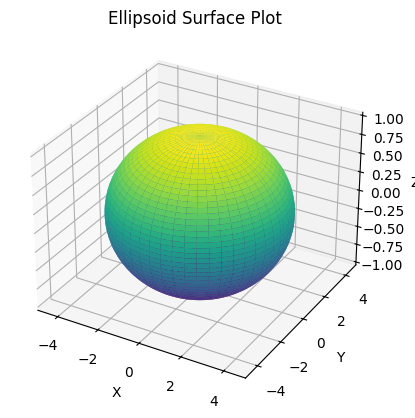

In [25]:
# Create a 3D surface plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.axes.set_xlim(-a-1, a+1)
ax.axes.set_ylim(-b-1, b+1)
ax.set_title('Ellipsoid Surface Plot')

plt.show()

In [ ]:
import numpy as np

def ellipsoid(a, b, c, center=(0,0,0), n=50):
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)

    x = a * np.outer(np.cos(u), np.sin(v))
    y = b * np.outer(np.sin(u), np.sin(v))
    z = c * np.outer(np.ones_like(u), np.cos(v))

    x += center[0]
    y += center[1]
    z += center[2]

    return x, y, z

In [5]:
umbilicus = (0, 0.2, 0)   # forward direction = y

In [6]:
abdomen = ellipsoid(a=0.15, b=0.25, c=0.18, center=umbilicus)

In [7]:
chest = ellipsoid(a=0.18, b=0.20, c=0.25, center=(0, 0.05, 0.1))

In [8]:
gluteus = ellipsoid(a=0.12, b=0.18, c=0.15, center=(0, -0.15, -0.05))

In [9]:
stages = {
    "9w":  {"abdomen_b": 0.20},
    "21w": {"abdomen_b": 0.28},
    "28w": {"abdomen_b": 0.34},
    "32w": {"abdomen_b": 0.38},
    "37w": {"abdomen_b": 0.42},
}

In [10]:
models = {}

for stage, params in stages.items():
    abdomen = ellipsoid(
        a=0.15,
        b=params["abdomen_b"],   # growth direction
        c=0.18,
        center=umbilicus
    )

    models[stage] = {
        "abdomen": abdomen
    }

In [11]:
electrodes = {
    "E1": np.array([0.0, 0.1, 0.1]),
    "E2": np.array([0.1, 0.1, 0.1]),
    "E3": np.array([0.0, 0.2, -0.1])
}

In [12]:
def project_to_ellipsoid(p, a, b, c):
    x, y, z = p
    scale = 1 / np.sqrt((x/a)**2 + (y/b)**2 + (z/c)**2)
    return np.array([x*scale, y*scale, z*scale])

In [13]:
displacements = {}

for key in electrodes:
    p_start = project_to_ellipsoid(electrodes[key], 0.15, 0.20, 0.18)
    p_end   = project_to_ellipsoid(electrodes[key], 0.15, 0.42, 0.18)

    displacements[key] = np.linalg.norm(p_end - p_start)

In [14]:
displacements

{'E1': np.float64(0.0447643268611361),
 'E2': np.float64(0.01953832779026677),
 'E3': np.float64(0.1101273783023983)}

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def ellipsoid_mesh(a, b, c, center=(0,0,0), n=60):
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)

    u, v = np.meshgrid(u, v)

    x = a * np.cos(u) * np.sin(v) + center[0]
    y = b * np.sin(u) * np.sin(v) + center[1]
    z = c * np.cos(v) + center[2]

    return x, y, z

In [16]:
stages = {
    "9w": 0.20,
    "21w": 0.28,
    "28w": 0.34,
    "32w": 0.38,
    "37w": 0.42
}

models = {}

for k, b in stages.items():
    x, y, z = ellipsoid_mesh(a=0.18, b=b, c=0.25)
    models[k] = (x, y, z)

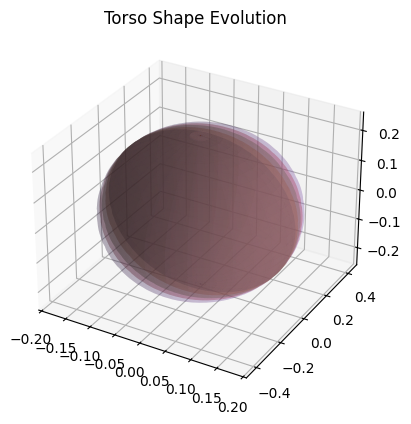

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for stage, (x, y, z) in models.items():
    ax.plot_surface(x, y, z, alpha=0.2)

ax.set_title("Torso Shape Evolution")
plt.show()